In [54]:
import pathlib
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.iolib


In [2]:
def build_filelist(basedir, glob_pattern):
    filelist = list(basedir.glob(glob_pattern))
    filelist.sort()
    return filelist

def filekey(filepath):
    file_key_re = re.compile("(Master_Stress_[0-9]*)/")
    m = file_key_re.search(str(filepath))
    return m.group(1)

In [32]:
def get_activity_monitor_df(data_dir, df_path):
    if df_path.exists():
        return pd.read_json(df_path)

    data = {}

    # Build up jobs dataframe from all activity monitor files
    filelist = build_filelist(data_dir, "Mixed_WOrkloads/Perflogs_*/*/Master_Stress_*/Activity*all_columns.txt")
    for filepath in filelist:
        print(f"Working on file: {filepath}")
        with open(filepath, "r") as f:
            for row in f:
                vals = row.split(",")

                job_id, start, end, files_str = int(vals[0]), int(vals[8]), int(vals[10]), vals[15]
                if files_str:
                    files = int(files_str)
                else:
                    files = 0

                if job_id in data:
                    # 0 is used to signify a null value
                    if start != 0:
                        data[job_id]["start"] = start
                    if end != 0:
                        data[job_id]["end"] = end
                    if files != 0:
                        data[job_id]["files"] = files
                else:
                    data[job_id] = {
                        "job_id": job_id,
                        "start": start,
                        "end": end,
                        "files": files,
                        "filepath": filekey(filepath)
                    }

    df = pd.DataFrame.from_dict(data, orient="index", columns={"job_id": int, "start": int, "end": int, "files": int, "filepath": str})
    # Remove any rows with null (0) values for start or end
    df.replace(0, np.nan, inplace=True)
    #df.dropna(inplace=True)
    df["duration"] = df["end"] - df["start"]
    
    #df.to_json(df_path)
    return df


In [4]:
def get_vmstat_df(data_dir, df_path):
    if df_path.exists():
        return pd.read_json(df_path)

    columns = [
        "time",
        "block",
        "r",
        "b",
        "swpd",
        "free",
        "buff",
        "cache",
        "si",
        "so",
        "bi",
        "bo",
        "in",
        "cs",
        "us",
        "sy",
        "id",
        "wa",
        "st",
    ]

    df = pd.DataFrame(columns=columns)

    for filepath in build_filelist(data_dir, "Mixed_WOrkloads/Perflogs_*/*/Master_Stress_*/vmstat.txt"):
        print(f"Working on file: {filepath}")
        with open(filepath, "r") as f:
            block = 0
            for row in f:
                if "memory" in row:
                    block += 1
                elif "swpd" in row:
                    continue
                else:
                    time = int(row.split()[6])
                    vals = [int(x) for x in row.split()[8:]]
                    append_me = {
                        field: int(val) for field, val in zip(columns, [time, block] + vals)
                    }
                    append_me["filepath"] = filekey(filepath)
                    df = df.append(append_me, ignore_index=True)

    df["cpu_pct"] = df["sy"].astype(int) + df["us"].astype(int) + df["wa"].astype(int)
    #df.to_json(df_path)
    return df


In [5]:
def get_combined_df(df_path, activity_monitor_df, vmstat_df):
    if df_path.exists():
        return pd.read_json(df_path)

    df = pd.DataFrame(columns=["time", "num_jobs", "swapout", "cpu_pct"], dtype=int)

    for _, row in vmstat_df.iterrows():
        cpu_pct = int(row["sy"]) + int(row["us"]) + int(row["wa"])
        swapout = int(row["so"])
        time_val = int(row["time"])

        # Count number of jobs
        jobs = activity_monitor_df.loc[
            (activity_monitor_df["start"] <= time_val)
            & (activity_monitor_df["end"] > time_val)
        ]
        num_jobs = len(jobs)

        df = df.append(
            {
                "time": time_val,
                "num_jobs": num_jobs,
                "swapout": swapout,
                "cpu_pct": cpu_pct,
            },
            ignore_index=True,
        )

    #df.to_json(df_path)
    return df


In [6]:
def get_cpu_pct_model(combined_df):
    model = smf.ols(formula="cpu_pct ~ num_jobs", data=combined_df)
    results = model.fit()
    return results


In [7]:
def cpu_pct_on_single_job(combined_df, model):
    overhead = model.params["Intercept"]
    combined_df["cpu_1_job"] = (combined_df["cpu_pct"] - overhead) / combined_df[
        "num_jobs"
    ]
    print(combined_df.head())


In [8]:
# Paths
RAW_DATA_DIR = pathlib.Path("../data/master-servers")

activity_monitor_df_path = RAW_DATA_DIR / "activity_monitor.json"
vmstat_df_path = RAW_DATA_DIR / "vmstat.json"
combined_df_path = RAW_DATA_DIR / "combined_df.json"


In [33]:
# Getting data frames
activity_monitor_df = get_activity_monitor_df(RAW_DATA_DIR, activity_monitor_df_path)
vmstat_df = get_vmstat_df(RAW_DATA_DIR, vmstat_df_path)
combined_df = get_combined_df(combined_df_path, activity_monitor_df, vmstat_df)


Working on file: ../data/master-servers/Mixed_WOrkloads/Perflogs_20201026-164212/eagappnbu104/Master_Stress_0000/ActivityMonitor_20201026_180423-all_columns.txt
Working on file: ../data/master-servers/Mixed_WOrkloads/Perflogs_20201026-164212/eagappnbu104/Master_Stress_0001/ActivityMonitor_20201026_190537-all_columns.txt
Working on file: ../data/master-servers/Mixed_WOrkloads/Perflogs_20201026-164212/eagappnbu104/Master_Stress_0002/ActivityMonitor_20201026_200636-all_columns.txt
Working on file: ../data/master-servers/Mixed_WOrkloads/Perflogs_20201026-164212/eagappnbu104/Master_Stress_0003/ActivityMonitor_20201026_210723-all_columns.txt
Working on file: ../data/master-servers/Mixed_WOrkloads/Perflogs_20201026-164212/eagappnbu104/Master_Stress_0004/ActivityMonitor_20201026_220815-all_columns.txt
Working on file: ../data/master-servers/Mixed_WOrkloads/Perflogs_20201026-164212/eagappnbu104/Master_Stress_0005/ActivityMonitor_20201026_230924-all_columns.txt
Working on file: ../data/master-se

In [36]:
groups = activity_monitor_df.groupby("files")
for name, group in groups:
    print(name, len(group))

10000.0 840
60000.0 780
110000.0 750
160000.0 690
210000.0 630
260000.0 570
310000.0 570
410000.0 480
460000.0 840
510000.0 390
560000.0 300
610000.0 300
660000.0 240
710000.0 180
760000.0 180
810000.0 150
820000.0 2
845000.0 1
850000.0 2
860000.0 119
870000.0 1
875000.0 1
880000.0 1
885000.0 2
895000.0 1
910000.0 84
1000000.0 56


In [18]:
model = get_cpu_pct_model(combined_df)

# Fit looks rather poor from summary - low R^2 value
model.summary()


/home/kushal/.pyenv/versions/anaconda3-2020.02/envs/vupc/lib/python3.7/site-packages/statsmodels/regression/linear_model.py:1827: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])
/home/kushal/.pyenv/versions/anaconda3-2020.02/envs/vupc/lib/python3.7/site-packages/statsmodels/base/model.py:1362: RuntimeWarning: invalid value encountered in true_divide
  return self.params / self.bse


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                cpu_pct   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Tue, 27 Oct 2020   Prob (F-statistic):                nan
Time:                        12:05:23   Log-Likelihood:                -15821.
No. Observations:                3614   AIC:                         3.164e+04
Df Residuals:                    3613   BIC:                         3.165e+04
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     83.0025      0.321    258.887      0.000      82.374      83.631
num_jobs            0          0        nan        nan           0           0
==============================================================================
Omnibus:                      483.825   Durbin-Watson:                   0.776
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              704.363
Skew:                          -1.080   Prob(JB):                    1.12e-153
Kurtosis:                       3.124   Cond. No.                          inf
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is      0. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [11]:
cpu_pct_on_single_job(combined_df, model)

         time  num_jobs  swapout  cpu_pct  cpu_1_job
0  1603749845       800        0        2  -0.039177
1  1603749855       818        0       29  -0.005307
2  1603749865       904        0       21  -0.013652
3  1603749875       913        0       50   0.018246
4  1603749885       914        0       57   0.025885


In [39]:
# Here we calculate mean job duration and mean CPU usage in every hourly dataset.
# The job duration used for modeling will be the reported mean duration adjusted
# according to CPU usage.

mean_durations = activity_monitor_df.groupby("filepath")["duration"]
cpu_group = vmstat_df.groupby("filepath")["cpu_pct"]
data = {}
for filepath, group in mean_durations:
    d = {"filepath": filepath}
    d["mean_duration"] = group.mean()
    d["mean_cpu"] = cpu_group.get_group(filepath).mean()
    data[filepath] = d
combined_df = pd.DataFrame.from_dict(data, orient="index", columns={"mean_duration": float, "mean_cpu": float})
combined_df["adjusted"] = (combined_df["mean_cpu"] / 100) * combined_df["mean_duration"]
combined_df

,mean_duration,mean_cpu,adjusted
Master_Stress_0000,2038.810273,80.207756,1635.283974
Master_Stress_0001,1896.155866,83.695291,1586.993167
Master_Stress_0002,2014.305328,80.047091,1612.392827
Master_Stress_0003,1947.260229,85.786704,1670.490361
Master_Stress_0004,2069.515342,81.052632,1677.396645
Master_Stress_0005,1985.176378,86.116343,1709.561309
Master_Stress_0006,2011.104916,80.486264,1618.663206
Master_Stress_0007,1947.495373,85.659280,1668.210510
Master_Stress_0008,1983.065217,80.176309,1589.948487
Master_Stress_0009,2147.875231,86.844444,1865.310312


In [20]:
# This will be the final job duration value for 10240 files/job
combined_df["adjusted"].mean()

nan

In [64]:
cpu_group = vmstat_df.groupby("filepath")["cpu_pct"].mean()
merged_df = pd.merge(activity_monitor_df, cpu_group, on=["filepath"])
merged_df["adjusted"] = merged_df["duration"] * merged_df["cpu_pct"] / 100

model = smf.ols(formula="adjusted ~ files:files + files", data=merged_df)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               adjusted   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                     1232.
Date:                Tue, 27 Oct 2020   Prob (F-statistic):          2.14e-251
Time:                        15:32:40   Log-Likelihood:                -63232.
No. Observations:                8147   AIC:                         1.265e+05
Df Residuals:                    8145   BIC:                         1.265e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1133.7140     10.398    109.029      0.000    1113.331    1154.097
files          0.0009   2.58e-05     35.095      0.000       0.001       0.001
==============================================================================
Omnibus:                     1113.325   Durbin-Watson:                   0.042
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              983.825
Skew:                          -0.771   Prob(JB):                    2.32e-214
Kurtosis:                       2.280   Cond. No.                     6.66e+05
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.66e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

ValueError: shapes (8147,2) and (1000,1) not aligned: 2 (dim 1) != 1000 (dim 0)

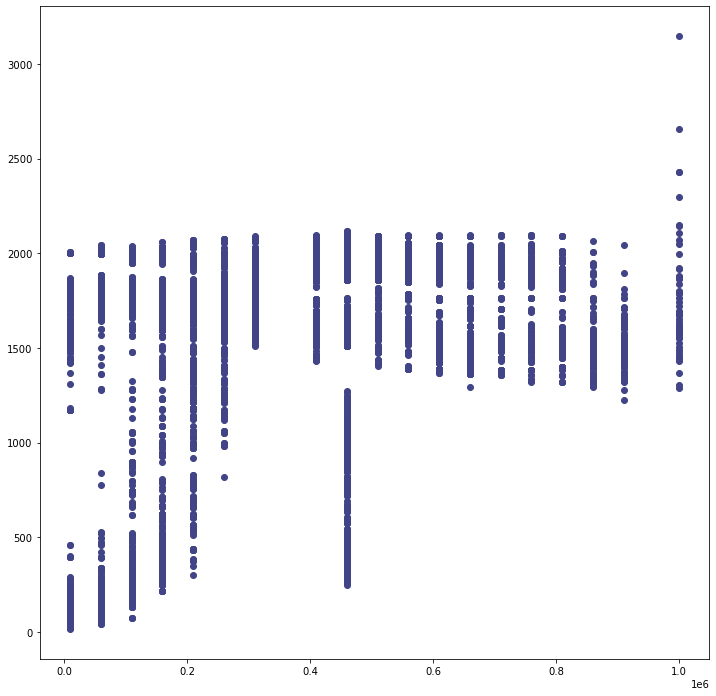

In [65]:
max_files = merged_df["files"].max()
fig, ax = plt.subplots(figsize=(12, 12))
colors = sns.color_palette("viridis", 4)
ax.scatter(merged_df["files"], merged_df["adjusted"], c=[colors[0]])
input_range = np.linspace(0, max_files, 1000)
pred_vals = model.predict(pd.DataFrame({"files": input_range}))
ax.plot(input_range, pred_vals, c=colors[1], ls="--")
ax.set(title="Master Server Validation", xlabel="Files", ylabel="Job runtime (sec)")